# 00_raw_eda · 192090 TIGER 차이나CSI300 (slot 15) — ETF Raw EDA

SSOT: `notebooks/_template/00_etf_raw_eda.ipynb` → `scripts/build_notebooks.py` 로 생성. 이 파일을 직접 고치지 말 것.

In [1]:
TICKER = "192090"
SLOT = 15

In [2]:
import sys, os, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display, Markdown
warnings.filterwarnings("ignore")
np.random.seed(0)

ROOT = Path.cwd().resolve()
while not (ROOT / "config" / "universe.csv").exists():
    if ROOT.parent == ROOT:
        raise FileNotFoundError("config/universe.csv not found")
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src import eda_utils as eu
from src.style import setup_notebook, banner, kpis
setup_notebook()
LIMITATIONS = [eu.LIMITATION_PRICE]
def cap(sec, st, extra=None):
    display(Markdown(eu.caption(sec, st, extra)))

## 00 Identity / Domain Card

In [3]:
U = eu.read_universe(ROOT)
row = U.loc[U["ticker"] == TICKER].iloc[0].to_dict()
banner(f"{TICKER} · {row.get('name','')}", f"UNIVERSE_STATUS={row.get('universe_status','PROVISIONAL') or 'PROVISIONAL'} — 공식 list 입수 시 교체")
display(pd.DataFrame([row]).T.rename(columns={0: "value"}))
KEYF = ["benchmark", "benchmark_proxy_ticker", "currency_hedge", "replication", "trading_hours_note", "structural_notes", "confidence"]
display(pd.DataFrame({"field": KEYF, "value": [row.get(k, "(missing column)") for k in KEYF]}))
print("price policy:", eu.PRICE_POLICY_UNADJ)

,value
slot,15
ticker,192090
name,TIGER 차이나CSI300
provider_brand,TIGER (미래에셋자산운용)
listing_date,2014-05
listing_date_source,"domain knowledge [ANA, uncertain]; FDR first r..."
data_start,2019-01-02
asset_scope,foreign_equity
category,broad_market
benchmark,CSI 300


,field,value
0,benchmark,CSI 300
1,benchmark_proxy_ticker,069500
2,currency_hedge,unhedged (추정)
3,replication,synthetic (추정; 스왑/현물 혼합 가능)
4,trading_hours_note,"KRX 거래, 중국장(KST 10:30-16:00)과 부분 중첩 → 동일일 반영 일..."
5,structural_notes,[OBS] Category=4. 중국 휴장(춘절·국경절) 시 가격 정체 가능 [ANA]
6,confidence,low


price policy: FDR Close — 조정가격 수익률(추정): FDR Close 는 분배 소급조정으로 추정(069500/KS200 누적비 1.155 ≈ TR 1.163), O/H/L 조정 일관성 미보장 — KNOWN_LIMITATION


### 00 · 이 ETF 는 무엇인가 (ETF-specific)
- **TIGER 차이나CSI300 (192090)** · foreign_equity / broad_market · 추종 CSI 300 · 레버리지 none · 환헤지 unhedged (추정) · 복제 synthetic (추정; 스왑/현물 혼합 가능).
- 거래시간: KRX 거래, 중국장(KST 10:30-16:00)과 부분 중첩 → 동일일 반영 일부, 중국 휴장일 상이.
- 비교 기준 ETF(benchmark proxy): 069500.
- UNIVERSE_STATUS=PROVISIONAL · 수익률은 조정가격 수익률(추정, DEC-3).

### ETF-specific reading (A card @69b99d3)
**정체성**

- [OBS] foreign_equity / broad_market / CSI 300 / peer_group CN_equity / 비헤지(추정) / synthetic(추정) / 중국장(KST 10:30~16:00)과 부분 중첩. confidence=low.
- [ANA] 중국 휴장(춘절·국경절) 중에도 KRX 에서는 거래 → 기초자산 가격 없이 거래되는 날이 생김.

## 01 Raw Data Audit

In [4]:
raw, PROV = eu.load_raw(eu.raw_path(TICKER))
print("price_policy:", PROV["price_policy"])
display(pd.DataFrame([{k: v for k, v in PROV.items() if k != "duplicate_dates"}]).T.rename(columns={0: "value"}))
display(eu.quality_summary(raw))
OHLC_BAD = eu.ohlc_violations(raw); GAPS = eu.date_gaps(raw, 5)
print("OHLC violations:", len(OHLC_BAD)); display(OHLC_BAD.head(10))
print("date gaps > 5 calendar days:", len(GAPS)); display(GAPS)
x, FLAGS = eu.engineer_basic(raw)
HAS_VOL = FLAGS["has_volume"]
if not HAS_VOL: LIMITATIONS.append("no_volume")
if FLAGS["n_zero_volume_days"] > 0: LIMITATIONS.append("zero_volume_days")
if len(x) < 500: LIMITATIONS.append("short_history")
if PROV["n_duplicate_dates"] > 0: LIMITATIONS.append("duplicate_dates")
START, END, N = x["date"].iloc[0], x["date"].iloc[-1], len(x)
ZERO_VOL_RATIO = FLAGS["n_zero_volume_days"] / N
print("first", START.date(), "last", END.date())

price_policy: FDR Close — 조정가격 수익률(추정): FDR Close 는 분배 소급조정으로 추정(069500/KS200 누적비 1.155 ≈ TR 1.163), O/H/L 조정 일관성 미보장 — KNOWN_LIMITATION


,value
source_file,/home/sieg/projects-wsl/hongik_univ_26_2/SA/ET...
rows_raw,1903
n_unparseable_dates,0
was_sorted,True
n_duplicate_dates,0
rows_after,1903
price_policy,FDR Close — 조정가격 수익률(추정): FDR Close 는 분배 소급조정으...
has_adj_close,False
has_volume,True
n_zero_volume_days,0


,column,dtype,n,missing_n,missing_pct,unique_n
0,date,datetime64[us],1903,0,0.0000,1903
1,open,int64,1903,0,0.0000,1295
2,high,int64,1903,0,0.0000,1279
3,low,int64,1903,0,0.0000,1299
4,close,int64,1903,0,0.0000,1282
5,volume,int64,1903,0,0.0000,1899
6,change,float64,1903,0,0.0000,1841
7,price,int64,1903,0,0.0000,1282


OHLC violations: 0


,date,open,high,low,close


date gaps > 5 calendar days: 9


,date,prev_date,gap_days
0,2019-02-07,2019-02-01,6
1,2020-10-05,2020-09-29,6
2,2021-09-23,2021-09-17,6
3,2022-02-03,2022-01-28,6
4,2023-10-04,2023-09-27,7
5,2024-09-19,2024-09-13,6
6,2025-01-31,2025-01-24,7
7,2025-10-10,2025-10-02,8
8,2026-02-19,2026-02-13,6


first 2019-01-02 last 2026-10-02


In [5]:
extra = [f"가격 정책: {PROV['price_policy']}"]
if not HAS_VOL: extra.append("거래량 컬럼이 없거나 전부 0 → 거래량 기반 분석 생략")
cap("01", {"rows_raw": PROV["rows_raw"], "rows_after": PROV["rows_after"], "n_duplicate_dates": PROV["n_duplicate_dates"],
           "n_unparseable_dates": PROV["n_unparseable_dates"], "was_sorted": PROV["was_sorted"], "ohlc_violations": len(OHLC_BAD),
           "n_gaps_gt5d": len(GAPS), "n_zero_volume_days": FLAGS["n_zero_volume_days"], "zero_vol_ratio": ZERO_VOL_RATIO,
           "first": START.date(), "last": END.date()}, extra)

#### 01 · WHAT WE SEE (raw values)
- `rows_raw` = 1903
- `rows_after` = 1903
- `n_duplicate_dates` = 0
- `n_unparseable_dates` = 0
- `was_sorted` = True
- `ohlc_violations` = 0
- `n_gaps_gt5d` = 9
- `n_zero_volume_days` = 0
- `zero_vol_ratio` = 0
- `first` = 2019-01-02
- `last` = 2026-10-02

#### General note · WHY IT MATTERS
행 수·중복·결측·날짜 공백은 이후 모든 rolling 창과 정렬(merge)의 기준이 된다. 감사되지 않은 행은 전처리 단계에서 조용히 왜곡을 만든다.

#### General note · WHAT WE DO NOT KNOW
- 원천(FDR) 이 휴장일 외의 누락을 어떻게 처리하는지는 이 데이터만으로 확인할 수 없다.
- 가격 정책: FDR Close — 조정가격 수익률(추정): FDR Close 는 분배 소급조정으로 추정(069500/KS200 누적비 1.155 ≈ TR 1.163), O/H/L 조정 일관성 미보장 — KNOWN_LIMITATION

#### General note · NEXT QUESTION
- 감사에서 걸린 행(중복/공백/OHLC 위반)을 전처리에서 제거·보간·flag 중 무엇으로 처리할 것인가?

> ETF 고유 해석은 바로 아래 'ETF-specific reading (A card)' 블록 참조


## 02 Whole-History Visual Scan

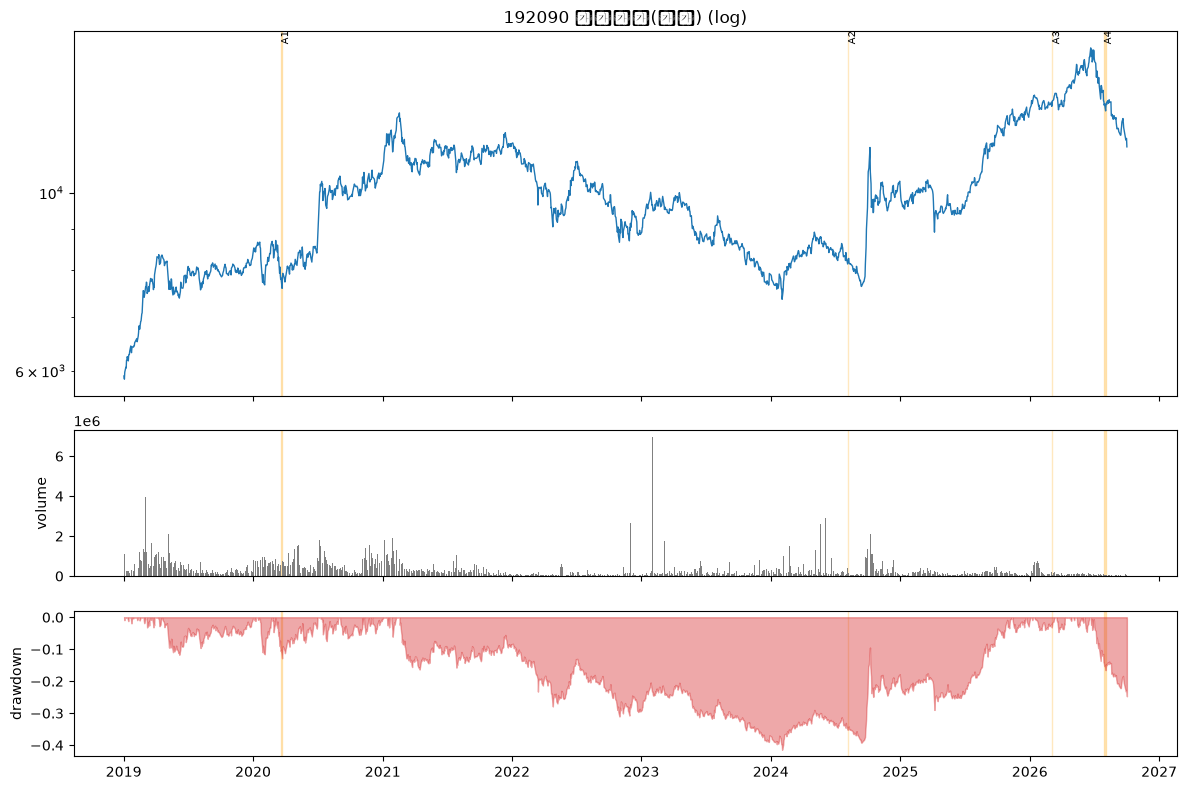

In [6]:
fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True, height_ratios=[3, 1.2, 1.2])
ax[0].plot(x["date"], x["price"], lw=1); ax[0].set_yscale("log"); ax[0].set_title(f"{TICKER} 조정가격(추정) (log)")
ANCH = eu.read_event_anchors(ROOT)
for _, a in ANCH.iterrows():
    s0, s1 = pd.to_datetime(a["start"], errors="coerce"), pd.to_datetime(a["end"] or a["start"], errors="coerce")
    if pd.notna(s0):
        for axx in ax: axx.axvspan(s0, s1 if pd.notna(s1) else s0, color="orange", alpha=.25)
        ax[0].text(s0, ax[0].get_ylim()[1], a.get("anchor_id", ""), fontsize=7, va="top", rotation=90)
if HAS_VOL: ax[1].bar(x["date"], x["volume"], width=1.5, color="gray")
else: ax[1].text(0.5, 0.5, "no volume", transform=ax[1].transAxes, ha="center")
ax[1].set_ylabel("volume")
ax[2].fill_between(x["date"], x["drawdown"], 0, color="tab:red", alpha=.4); ax[2].set_ylabel("drawdown")
plt.tight_layout(); plt.show()

In [7]:
cap("02", {"price_first": x["price"].iloc[0], "price_last": x["price"].iloc[-1],
           "price_min": x["price"].min(), "price_max": x["price"].max(), "min_drawdown": x["drawdown"].min(),
           "volume_median": x["volume"].median() if HAS_VOL else "n/a"})

#### 02 · WHAT WE SEE (raw values)
- `price_first` = 5910
- `price_last` = 11405
- `price_min` = 5856
- `price_max` = 15150
- `min_drawdown` = -0.4143
- `volume_median` = 1.49e+05

#### General note · WHY IT MATTERS
전체 이력의 수준·거래량·낙폭을 한 화면에서 보면 구조 변화(regime)나 이상 구간이 있는지, 정규화 창을 어디서 끊어야 할지 판단할 근거가 된다.

#### General note · WHAT WE DO NOT KNOW
- 가격 점프가 분배금/분할 때문인지 실제 가격 변동인지 이 데이터만으로 구분할 수 없다.

#### General note · NEXT QUESTION
- 전체 기간을 하나의 정규화 창으로 볼 수 있는가, 아니면 구간을 나눠야 하는가?

> ETF 고유 해석은 바로 아래 'ETF-specific reading (A card)' 블록 참조


## 03 Return Distribution

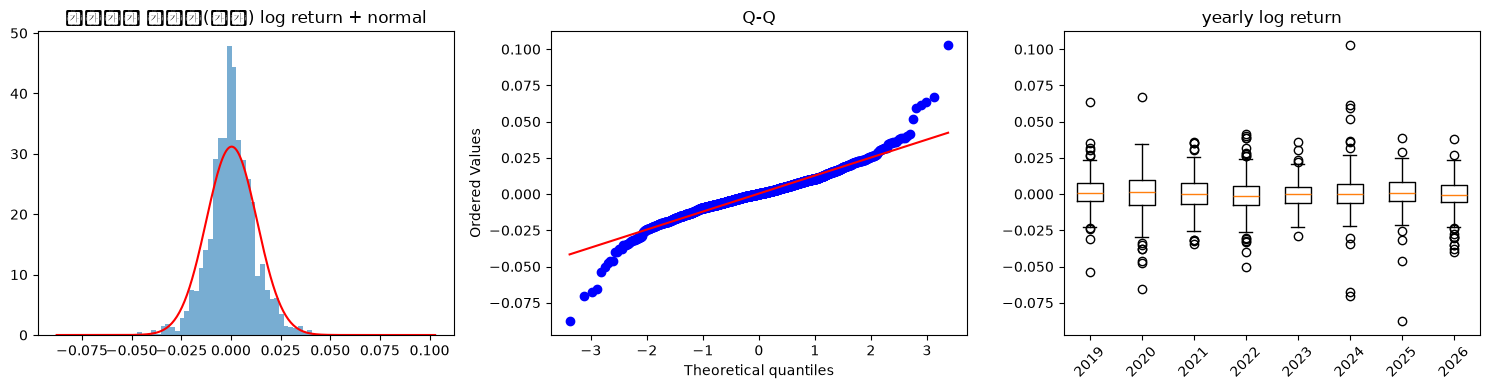

In [8]:
r = x["log_ret"].dropna()
K = {"mean": r.mean(), "std": r.std(), "ann_vol": r.std() * np.sqrt(252), "skew": stats.skew(r),
     "ex_kurt": stats.kurtosis(r), "ex_kurt_trim3": eu.kurt_trim(r, 3), "p01": r.quantile(.01), "p99": r.quantile(.99), "n": len(r)}
kpis([(k, f"{v:.4g}") for k, v in K.items()])
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].hist(r, bins=80, density=True, alpha=.6); g = np.linspace(r.min(), r.max(), 300)
ax[0].plot(g, stats.norm.pdf(g, r.mean(), r.std()), "r-"); ax[0].set_title("조정가격 수익률(추정) log return + normal")
stats.probplot(r, dist="norm", plot=ax[1]); ax[1].set_title("Q-Q")
yr = x.dropna(subset=["log_ret"]).groupby(x["date"].dt.year)["log_ret"]
ax[2].boxplot([v.values for _, v in yr], tick_labels=[str(k) for k, _ in yr]); ax[2].set_title("yearly log return")
ax[2].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

In [9]:
cap("03", K)

#### 03 · WHAT WE SEE (raw values)
- `mean` = 0.0003456
- `std` = 0.01279
- `ann_vol` = 0.203
- `skew` = 0.04355
- `ex_kurt` = 6.107
- `ex_kurt_trim3` = 3.143
- `p01` = -0.03372
- `p99` = 0.03426
- `n` = 1902

#### General note · WHY IT MATTERS
수익률 분포의 꼬리(첨도·왜도·분위수)는 z-score 같은 정규 가정 기반 정규화가 얼마나 맞지 않는지를 직접 보여준다.

#### General note · WHAT WE DO NOT KNOW
- 분포 모양이 기간에 따라 안정적인지는 단일 전체표본 통계로는 알 수 없다.

#### General note · NEXT QUESTION
- 꼬리 두께를 감안할 때 z-score 대신 robust/분위수 기반 정규화가 필요한가?

> ETF 고유 해석은 바로 아래 'ETF-specific reading (A card)' 블록 참조


### 03 · WHAT WE SEE — 이 ETF (universe 20종 비교, B 계산)
- **연환산 변동성 20.3%** — 20종 중 15위(높은 순), 백분위 30%, 069500 의 0.71배 (universe 중앙값 28.4%).
- **초과첨도(full) 6.1** — 20종 중 15위(높은 순), 백분위 30%, 069500 의 0.32배 (universe 중앙값 10.5).
- **초과첨도(상위 |r| 3일 제외) 3.1** — 20종 중 13위(높은 순), 백분위 40%, 069500 의 0.40배 (universe 중앙값 3.9).
- **왜도 +0.04** — 20종 중 6위(높은 순), 백분위 75%, 069500 의 0.27배 (universe 중앙값 -0.11).
- **일간 로그수익률 1% 분위 -3.37%** — 20종 중 15위(낮은(더 극단) 순), 백분위 30%, 069500 의 0.57배 (universe 중앙값 -5.18%).
- **일간 로그수익률 99% 분위 +3.43%** — 20종 중 15위(높은 순), 백분위 30%, 069500 의 0.65배 (universe 중앙값 +5.15%).

- **DQ 각주 · spike_reversal_candidate** (2일): 2024-10-07, 2024-10-08. 고립 급등-반전 후보, DQ 미확정 — 실제 사건일 수 있음

### ETF-specific reading (A card @69b99d3)
**평소 움직임**

- [OBS] ann_vol 20.3% / exw 20.2%; skew **+0.04** / exw +0.05 (5개 중 유일하게 양); kurt full 6.11 · trim3 3.14 · exw 6.22.
- [OBS] q01 −3.37% / q99 +3.43%; |r| q95 2.43% / q99 3.86%; 누적 +93%, ann_ret 8.7% (5개 중 최저).
- [OBS] 연도별 ann vol: 2019 18.7 · 2020 23.9 · 2021 18.9 · 2022 21.1 · 2023 15.1 · **2024 24.6** · 2025 18.9 · 2026 19.2(%) — 연도 간 차이가 가장 작음.
- [OBS] 수익률 0 인 날 52일.

### 03b Core stats — full / by year / 2026-07-20~08-10 제외 / DQ 포함 vs 제외

In [10]:
SV, DQ_NOTE = eu.stats_variants(x, ROOT, TICKER)
display(SV); print("DQ:", DQ_NOTE)
if DQ_NOTE != "no_dq_flags": LIMITATIONS.append("dq_flagged_dates")  # 해당일 포함/제외 병기됨
exk = [i for i in SV.index if i.startswith("excl_")][0]
cap("03", {"full_ann_vol": SV.loc["full", "ann_vol"], "excl_window_ann_vol": SV.loc[exk, "ann_vol"],
           "full_ex_kurt": SV.loc["full", "ex_kurt"], "excl_window_ex_kurt": SV.loc[exk, "ex_kurt"],
           "dq_excluded_ex_kurt": SV.loc["dq_excluded", "ex_kurt"], "dq_note": DQ_NOTE,
           "year_ann_vol_min": SV.filter(like="year_", axis=0)["ann_vol"].min(), "year_ann_vol_max": SV.filter(like="year_", axis=0)["ann_vol"].max()})

,n,ann_vol,ex_kurt,ex_kurt_trim3,p01,p99,max_dd
full,"1,902.0000",0.2030,6.1070,3.1431,-0.0337,0.0343,-0.4143
year_2019,245.0000,0.1870,4.5027,0.4365,-0.0238,0.0312,-0.1173
year_2020,248.0000,0.2385,2.7428,0.4984,-0.0423,0.0320,-0.1284
year_2021,248.0000,0.1893,0.7927,0.5334,-0.0317,0.0332,-0.1634
year_2022,246.0000,0.2112,1.4632,0.8325,-0.0329,0.0386,-0.2481
year_2023,245.0000,0.1513,0.8792,0.0007,-0.0198,0.0230,-0.2338
year_2024,244.0000,0.2461,11.2485,4.2605,-0.0327,0.0560,-0.1706
year_2025,242.0000,0.1888,12.7526,0.4013,-0.0291,0.0244,-0.1388
year_2026,184.0000,0.1919,1.4347,0.9079,-0.0358,0.0238,-0.2472
excl_2026-07-20~2026-08-10,"1,886.0000",0.2022,6.2232,3.1837,-0.0331,0.0324,-0.4143


DQ: no_dq_flags


#### 03 · WHAT WE SEE (raw values)
- `full_ann_vol` = 0.203
- `excl_window_ann_vol` = 0.2022
- `full_ex_kurt` = 6.107
- `excl_window_ex_kurt` = 6.223
- `dq_excluded_ex_kurt` = 6.107
- `dq_note` = no_dq_flags
- `year_ann_vol_min` = 0.1513
- `year_ann_vol_max` = 0.2461

#### General note · WHY IT MATTERS
수익률 분포의 꼬리(첨도·왜도·분위수)는 z-score 같은 정규 가정 기반 정규화가 얼마나 맞지 않는지를 직접 보여준다.

#### General note · WHAT WE DO NOT KNOW
- 분포 모양이 기간에 따라 안정적인지는 단일 전체표본 통계로는 알 수 없다.

#### General note · NEXT QUESTION
- 꼬리 두께를 감안할 때 z-score 대신 robust/분위수 기반 정규화가 필요한가?

> ETF 고유 해석은 바로 아래 'ETF-specific reading (A card)' 블록 참조


## 04 Volatility Dynamics

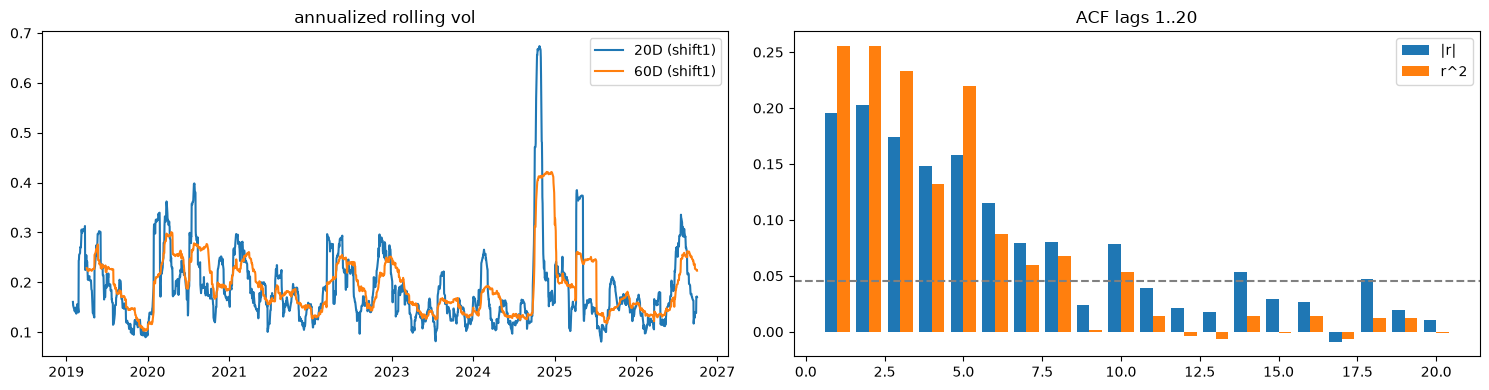

,lag,acf_absret,acf_sqret
0,1,0.1957,0.2554
1,2,0.2023,0.2553
2,3,0.1738,0.2329
3,4,0.1483,0.1324
4,5,0.1577,0.2196
5,6,0.1150,0.0870
6,7,0.0795,0.0600
7,8,0.0806,0.0676
8,9,0.0236,0.0014
9,10,0.0788,0.0533


,lb_stat,lb_pvalue
5,298.0135,0.0000
10,360.7229,0.0000
20,379.0186,0.0000


In [11]:
ACF_ABS = eu.acf(x["abs_ret"], 20); ACF_SQ = eu.acf(x["log_ret"] ** 2, 20)
VOL_OF_VOL = float((x["roll_vol_20"] / x["roll_vol_20"].mean()).std())
from statsmodels.stats.diagnostic import acorr_ljungbox
LB = acorr_ljungbox(x["abs_ret"].dropna(), lags=[5, 10, 20])
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
ax[0].plot(x["date"], x["roll_vol_20"] * np.sqrt(252), label="20D (shift1)")
ax[0].plot(x["date"], x["roll_vol_60"] * np.sqrt(252), label="60D (shift1)"); ax[0].legend(); ax[0].set_title("annualized rolling vol")
lags = np.arange(1, 21)
ax[1].bar(lags - .2, ACF_ABS, .4, label="|r|"); ax[1].bar(lags + .2, ACF_SQ, .4, label="r^2")
ax[1].axhline(1.96 / np.sqrt(len(x)), ls="--", c="gray"); ax[1].legend(); ax[1].set_title("ACF lags 1..20")
plt.tight_layout(); plt.show()
display(pd.DataFrame({"lag": lags, "acf_absret": ACF_ABS, "acf_sqret": ACF_SQ}).head(10)); display(LB)

In [12]:
cap("04", {"acf_absret_lag1": ACF_ABS[0], "acf_absret_lag5": ACF_ABS[4], "acf_sqret_lag1": ACF_SQ[0],
           "vol_of_vol(cv of roll_vol_20)": VOL_OF_VOL, "ljungbox_absret_lag20_p": LB["lb_pvalue"].iloc[-1],
           "roll_vol_20_ann_median": x["roll_vol_20"].median() * np.sqrt(252)})

#### 04 · WHAT WE SEE (raw values)
- `acf_absret_lag1` = 0.1957
- `acf_absret_lag5` = 0.1577
- `acf_sqret_lag1` = 0.2554
- `vol_of_vol(cv of roll_vol_20)` = 0.4111
- `ljungbox_absret_lag20_p` = 4.54e-68
- `roll_vol_20_ann_median` = 0.1684

#### General note · WHY IT MATTERS
변동성 군집(|r|, r^2 의 자기상관)이 있으면 고정 임계값보다 시간가변 baseline 정규화가 필요하다는 근거가 된다.

#### General note · WHAT WE DO NOT KNOW
- 표본이 크면 Ljung-Box 는 작은 자기상관도 유의하게 만든다 — 유의성은 크기의 증거가 아니다.

#### General note · NEXT QUESTION
- baseline 창 길이(20 vs 60)를 무엇으로 고를 것인가?

> ETF 고유 해석은 바로 아래 'ETF-specific reading (A card)' 블록 참조


### 04 · WHAT WE SEE — 이 ETF (universe 20종 비교, B 계산)
- **|r| lag1 자기상관(변동성 군집) 0.196** — 20종 중 19위(높은 순), 백분위 10%, 069500 의 0.52배 (universe 중앙값 0.302).
- **vol-of-vol 0.411** — 20종 중 19위(높은 순), 백분위 10%, 069500 의 0.54배 (universe 중앙값 0.544).

### ETF-specific reading (A card @69b99d3)
**변동성 구조**

- [OBS] acf_abs1/5/20 = 0.196 / 0.158 / **0.010** (5개 중 acf_abs1·20 최저); lag1 ACF of r = 0.021.
- [OBS] 20D rolling vol median 16.8%, p90/p10 **2.40**(5개 중 최소); vol_ratio_hi_lo 2.15(최소). 60d vol 최고 2024-11-25 42.1%, 최저 2019-12-12 10.3%.
- [ANA] 변동성 군집이 약함 — 큰 날이 '뭉쳐서'보다 '단발로' 온다.

## 05 Trading Activity

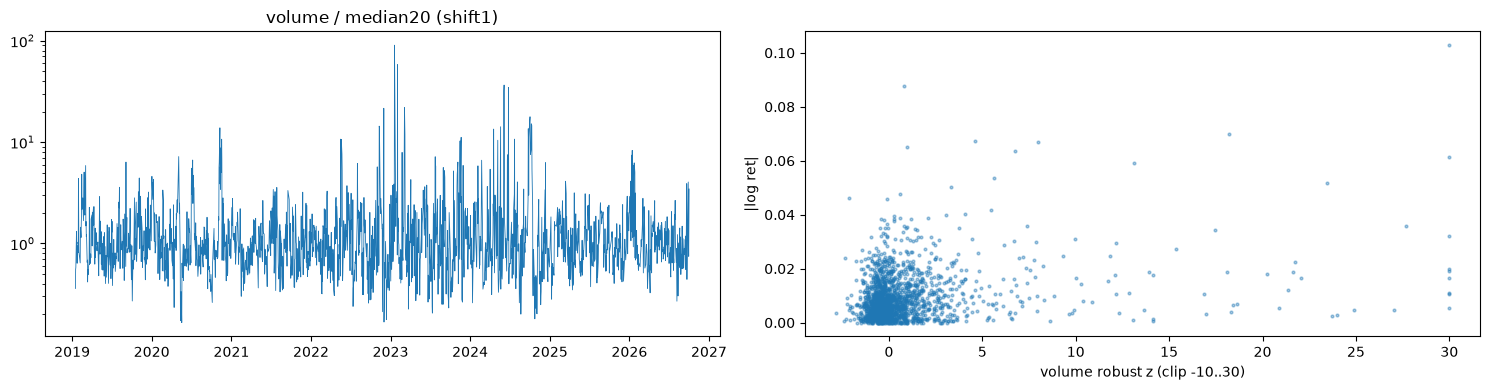

In [13]:
VOLST = {}
if HAS_VOL:
    vz = x["volume_robust_z_20"]
    rho, p = stats.spearmanr(x["abs_ret"], vz, nan_policy="omit")
    ext = x["abs_q95"].fillna(False)
    VOLST = {"spearman_absret_volz": rho, "spearman_p": p, "volz_median_extreme(abs_q95)": vz[ext].median(),
             "volz_median_normal": vz[~ext].median(), "volratio_median_extreme": x["volume_ratio_20"][ext].median(),
             "volratio_median_normal": x["volume_ratio_20"][~ext].median(), "n_mad_zero": FLAGS["n_mad_zero"]}
    fig, ax = plt.subplots(1, 2, figsize=(15, 4))
    ax[0].plot(x["date"], x["volume_ratio_20"], lw=.6); ax[0].set_yscale("log"); ax[0].set_title("volume / median20 (shift1)")
    ax[1].scatter(vz.clip(-10, 30), x["abs_ret"], s=4, alpha=.4); ax[1].set_xlabel("volume robust z (clip -10..30)"); ax[1].set_ylabel("|log ret|")
    plt.tight_layout(); plt.show()
else:
    print("SKIP: 거래량 없음 (has_volume=False)")
    VOLST = {"skipped": "no_volume"}

In [14]:
cap("05", VOLST, None if HAS_VOL else ["거래량이 없어 이 절 분석을 생략했다."])

#### 05 · WHAT WE SEE (raw values)
- `spearman_absret_volz` = 0.1932
- `spearman_p` = 2.651e-17
- `volz_median_extreme(abs_q95)` = 1.069
- `volz_median_normal` = -0.1205
- `volratio_median_extreme` = 1.578
- `volratio_median_normal` = 0.9254
- `n_mad_zero` = 0

#### General note · WHY IT MATTERS
거래량 baseline(shift(1))과 수익률 크기의 관계는 거래량을 극단 후보의 보조 신호로 쓸 수 있는지에 대한 근거가 된다.

#### General note · WHAT WE DO NOT KNOW
- 거래량 급증의 원인(설정/환매, LP 호가, 리밸런싱)은 이 데이터에 없다.

#### General note · NEXT QUESTION
- 거래량 robust z 를 극단 후보의 보조 조건으로 쓸 가치가 있는가?

> ETF 고유 해석은 바로 아래 'ETF-specific reading (A card)' 블록 참조


### 05 · WHAT WE SEE — 이 ETF (universe 20종 비교, B 계산)
- **거래량 0 일 비율 0.00%** — 20종 중 1위(높은 순), 백분위 100% (universe 중앙값 0.00%).

### ETF-specific reading (A card @69b99d3)
**거래활동**

- [OBS] med_volume 149,045; zero_vol_days 0; corr(|r|, Δlog volume) 0.146.
- [OBS] 상위5 극단일 volume ratio ≥2 동반 **3/5** (5개 중 최고) — 모두 2024-09~10 (15~18배).

## 06 Drawdown / Recovery / Persistence

In [15]:
EP = eu.drawdown_episodes(x["price"], x["date"], 5)
i_min = int(x["drawdown"].idxmin()); MAX_DD = float(x["drawdown"].min()); MAX_DD_DATE = x["date"].iloc[i_min].date()
rec = x.index[(x.index > i_min) & (x["drawdown"] >= 0)]
RECOVERY_DAYS = int((x["date"].iloc[rec[0]] - x["date"].iloc[i_min]).days) if len(rec) else None
display(EP)
lp = np.log(x["price"])
fw = {}
for h in (1, 3, 5, 10):
    f = lp.shift(-h) - lp
    fw[h] = {"pos_q95": f[x["pos_q95"]].mean(), "neg_q05": f[x["neg_q05"]].mean(), "all": f.mean()}
FWD = pd.DataFrame(fw).T.rename_axis("h"); display(FWD)
print("※ EDA-only: 겹치는 표본, full-sample 분위수(look-ahead).")

,peak_date,trough_date,depth,recovery_date,recovery_days
0,2021-02-17,2024-02-02,-0.4143,2025-11-13,650.0000
1,2026-06-22,2026-10-02,-0.2472,None,NaN
2,2020-03-05,2020-03-23,-0.1284,2020-07-02,101.0000
3,2019-04-10,2019-06-07,-0.1173,2020-01-02,209.0000
4,2020-01-20,2020-02-03,-0.1156,2020-02-24,21.0000


,pos_q95,neg_q05,all
h,,,
1,0.0008,0.0004,0.0003
3,0.0081,0.0012,0.0011
5,0.0093,0.0013,0.0018
10,0.0072,0.0018,0.0035


※ EDA-only: 겹치는 표본, full-sample 분위수(look-ahead).


In [16]:
cap("06", {"max_dd": MAX_DD, "max_dd_date": MAX_DD_DATE, "recovery_days": RECOVERY_DAYS if RECOVERY_DAYS is not None else "not recovered",
           "fwd5_after_pos_q95": FWD.loc[5, "pos_q95"], "fwd5_after_neg_q05": FWD.loc[5, "neg_q05"], "fwd5_all": FWD.loc[5, "all"]})

#### 06 · WHAT WE SEE (raw values)
- `max_dd` = -0.4143
- `max_dd_date` = 2024-02-02
- `recovery_days` = 650
- `fwd5_after_pos_q95` = 0.009295
- `fwd5_after_neg_q05` = 0.00125
- `fwd5_all` = 0.001754

#### General note · WHY IT MATTERS
낙폭 깊이·회복 기간·극단일 이후 forward return 은 이벤트 창 길이와 사후 관측 구간 설계의 근거가 된다.

#### General note · WHAT WE DO NOT KNOW
- forward return 은 겹치는 표본(overlapping)이라 독립 관측 수가 실제보다 적다. 인과가 아니다.

#### General note · NEXT QUESTION
- 극단일 이후 며칠까지를 이벤트 창으로 볼 것인가?

> ETF 고유 해석은 바로 아래 'ETF-specific reading (A card)' 블록 참조


### 06 · WHAT WE SEE — 이 ETF (universe 20종 비교, B 계산)
- **최대 낙폭 -41.4%** — 20종 중 12위(낮은(더 극단) 순), 백분위 45%, 069500 의 1.02배 (universe 중앙값 -47.5%).
- **최대 낙폭 회복일수 650** — 12종 중 4위(높은 순), 백분위 45% (universe 중앙값 377).

### ETF-specific reading (A card @69b99d3)
**언제 이상해지는가**

- [OBS] max_dd −41.4%: peak 2021-02-17 → trough 2024-02-02 (약 3년 하락) → recovered 2025-11-13 (430 거래일). 현재 dd −24.7%.

## 07 Candidate Extreme Windows

최종 label/threshold 아님. z 후보는 shift(1) baseline, q 후보는 full-sample(look-ahead).

,definition,n_days
0,pos_z2,67
1,neg_z2,62
2,abs_z2,129
3,pos_z2_5,34
4,neg_z2_5,30
5,abs_z2_5,64
6,pos_z3,18
7,neg_z3,15
8,abs_z3,33
9,pos_q95,96


,abs_z2,abs_z2_5,abs_z3,abs_q95
abs_z2,1.0000,0.4961,0.2558,0.3889
abs_z2_5,0.4961,1.0000,0.5156,0.3559
abs_z3,0.2558,0.5156,1.0000,0.2772
abs_q95,0.3889,0.3559,0.2772,1.0000


,date,price,log_ret,ret_z20,roll_vol_20
1539,2025-04-07,8929,-0.0878,-8.7878,0.0100
35,2019-02-25,7548,0.0637,7.2446,0.0088
83,2019-05-07,7787,-0.0537,-6.5938,0.0082
372,2020-07-06,9777,0.0668,5.5096,0.0121
262,2020-01-28,7729,-0.0652,-5.4095,0.0121
1771,2026-03-23,12685,-0.0352,-5.3017,0.0066
1127,2023-07-25,8929,0.0358,4.9006,0.0073
1416,2024-10-02,10614,0.1028,4.8411,0.0212
1477,2025-01-02,9870,-0.0459,-4.5904,0.0100
1523,2025-03-14,10324,0.0288,4.2511,0.0068


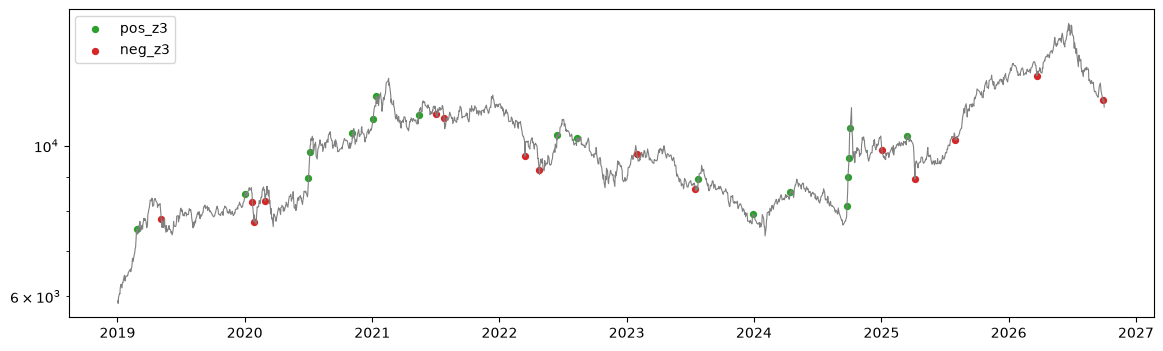

In [17]:
DEFS = [c for c in x.columns if c.startswith(("pos_z", "neg_z", "abs_z")) or c in ("pos_q95", "neg_q05", "abs_q95")]
CNT = pd.DataFrame({"definition": DEFS, "n_days": [int(x[c].sum()) for c in DEFS]}); display(CNT)
absdefs = ["abs_z2", "abs_z2_5", "abs_z3", "abs_q95"]
JAC = pd.DataFrame([[eu.jaccard(x[a], x[b]) for b in absdefs] for a in absdefs], index=absdefs, columns=absdefs); display(JAC)
TOP = x.loc[x["ret_z20"].abs().nlargest(10).index, ["date", "price", "log_ret", "ret_z20", "roll_vol_20"]]; display(TOP)
fig, ax = plt.subplots(figsize=(14, 4)); ax.plot(x["date"], x["price"], lw=.8, c="gray"); ax.set_yscale("log")
ax.scatter(x["date"][x["pos_z3"]], x["price"][x["pos_z3"]], c="tab:green", s=18, label="pos_z3")
ax.scatter(x["date"][x["neg_z3"]], x["price"][x["neg_z3"]], c="tab:red", s=18, label="neg_z3"); ax.legend(); plt.show()
N_POS3, N_NEG3, N_ABS3 = int(x["pos_z3"].sum()), int(x["neg_z3"].sum()), int(x["abs_z3"].sum())

### 07b 정의별 극단일 표 (① abs% q95 ② shift(1) robust z w60 k3 ③ percentile q01/q99)

In [18]:
XDEF, XSC = eu.extreme_definitions(x)
for nm, msk in XDEF.items():
    t = x.loc[msk, ["date", "ret_1d", "log_ret"]].assign(score=XSC[nm][msk])
    print(f"[{nm}] n_days={int(msk.sum())}"); display(t.nlargest(10, "score"))
ks = list(XDEF)
JAC3 = {f"{ks[i]}~{ks[j]}": eu.jaccard(XDEF[ks[i]], XDEF[ks[j]]) for i in range(3) for j in range(i + 1, 3)}
print("Jaccard: " + " | ".join(f"{k}={v:.3f}" for k, v in JAC3.items()))

[abs_pct_q95] n_days=96


,date,ret_1d,log_ret,score
1416,2024-10-02,0.1083,0.1028,0.1083
1539,2025-04-07,-0.0840,-0.0878,0.0840
372,2020-07-06,0.0691,0.0668,0.0691
1419,2024-10-08,-0.0676,-0.0700,0.0676
35,2019-02-25,0.0658,0.0637,0.0658
1421,2024-10-11,-0.0652,-0.0675,0.0652
1415,2024-09-30,0.0634,0.0615,0.0634
262,2020-01-28,-0.0632,-0.0652,0.0632
1418,2024-10-07,0.0610,0.0592,0.0610
1414,2024-09-27,0.0532,0.0518,0.0532


[robust_z_shift1_w60_k3] n_days=61


,date,ret_1d,log_ret,score
1416,2024-10-02,0.1083,0.1028,12.7563
1539,2025-04-07,-0.0840,-0.0878,11.1093
1415,2024-09-30,0.0634,0.0615,8.5048
262,2020-01-28,-0.0632,-0.0652,7.9981
1419,2024-10-08,-0.0676,-0.0700,7.2135
1414,2024-09-27,0.0532,0.0518,7.1997
1418,2024-10-07,0.0610,0.0592,6.9850
1421,2024-10-11,-0.0652,-0.0675,6.1630
83,2019-05-07,-0.0523,-0.0537,5.8525
372,2020-07-06,0.0691,0.0668,5.3675


[pctile_q01_q99] n_days=40


,date,ret_1d,log_ret,score
1416,2024-10-02,0.1083,0.1028,0.1083
1539,2025-04-07,-0.0840,-0.0878,0.0840
372,2020-07-06,0.0691,0.0668,0.0691
1419,2024-10-08,-0.0676,-0.0700,0.0676
35,2019-02-25,0.0658,0.0637,0.0658
1421,2024-10-11,-0.0652,-0.0675,0.0652
1415,2024-09-30,0.0634,0.0615,0.0634
262,2020-01-28,-0.0632,-0.0652,0.0632
1418,2024-10-07,0.0610,0.0592,0.0610
1414,2024-09-27,0.0532,0.0518,0.0532


Jaccard: abs_pct_q95~robust_z_shift1_w60_k3=0.510 | abs_pct_q95~pctile_q01_q99=0.417 | robust_z_shift1_w60_k3~pctile_q01_q99=0.464


In [19]:
cap("07", {"n_pos_z3": N_POS3, "n_neg_z3": N_NEG3, "n_abs_z3": N_ABS3, "n_abs_z2": int(x["abs_z2"].sum()),
           "n_abs_q95": int(x["abs_q95"].sum()), "jaccard_abs_z3_vs_abs_q95": JAC.loc["abs_z3", "abs_q95"],
           "jaccard_abs_z2_vs_abs_z3": JAC.loc["abs_z2", "abs_z3"], **{f"n_{k}": int(v.sum()) for k, v in XDEF.items()}, **{f"jac_{k}": v for k, v in JAC3.items()}, "max_abs_ret_z20": x["ret_z20"].abs().max()})

#### 07 · WHAT WE SEE (raw values)
- `n_pos_z3` = 18
- `n_neg_z3` = 15
- `n_abs_z3` = 33
- `n_abs_z2` = 129
- `n_abs_q95` = 96
- `jaccard_abs_z3_vs_abs_q95` = 0.2772
- `jaccard_abs_z2_vs_abs_z3` = 0.2558
- `n_abs_pct_q95` = 96
- `n_robust_z_shift1_w60_k3` = 61
- `n_pctile_q01_q99` = 40
- `jac_abs_pct_q95~robust_z_shift1_w60_k3` = 0.5096
- `jac_abs_pct_q95~pctile_q01_q99` = 0.4167
- `jac_robust_z_shift1_w60_k3~pctile_q01_q99` = 0.4638
- `max_abs_ret_z20` = 8.788

#### General note · WHY IT MATTERS
후보 정의마다 선택되는 날이 얼마나 겹치는지는 극단 정의가 정의 선택에 얼마나 민감한지를 보여준다 (최종 정의는 여기서 정하지 않는다).

#### General note · WHAT WE DO NOT KNOW
- q95/q05 후보는 전체표본 분위수(look-ahead) 이므로 실시간 탐지에는 쓸 수 없다.

#### General note · NEXT QUESTION
- 후보 정의 간 불일치가 큰 날들은 어떤 공통 특성을 갖는가?

> ETF 고유 해석은 바로 아래 'ETF-specific reading (A card)' 블록 참조


### 07 · WHAT WE SEE — 이 ETF (universe 20종 비교, B 계산)
- **|z|≥3 후보일(shift(1) 20D vol 기준) 33** — 20종 중 11위(높은 순), 백분위 50%, 069500 의 1.00배 (universe 중앙값 34).
- **z≥+3 후보일 18** — 20종 중 6위(높은 순), 백분위 75%, 069500 의 1.50배 (universe 중앙값 14).
- **z≤−3 후보일 15** — 20종 중 18위(높은 순), 백분위 15%, 069500 의 0.71배 (universe 중앙값 19).

- **DQ 각주 · spike_reversal_candidate** (2일): 2024-10-07, 2024-10-08. 고립 급등-반전 후보, DQ 미확정 — 실제 사건일 수 있음

### ETF-specific reading (A card @69b99d3)
**언제 이상해지는가**

- [OBS] 상위 5 |robust-z|: 2024-10-02 +10.3% (rz 12.3, univ median −0.3%, fwd5 −10.2%, vr 17.8배) · 2025-04-07 −8.8% (−9.3, −5.9%) · 2024-10-08 −7.0% (−7.8, −0.1%, vr 15.1배) · 2020-01-28 −6.5% (−7.4, −2.6%) · 2024-09-30 +6.2% (7.4, −1.0%, vr 15.8배).
- [OBS] → **고유 3/5**(2024-09-30, 10-02, 10-08: univ median 0 근처), 공통 2/5. common_shock_days 55일 중 12일만 참여(5개 중 최소).
- [OBS] 극단일 정의 |robust-z|>3; trailing 60d std shift1 |z|>3 27일, >4 11일.
- [OBS] 2024-09-26~10-11 일별: +2.6, +5.2, +6.2, +10.3(10-02), +1.1, +5.9, −7.0(10-08), −3.4, −6.8% → 급등 후 급락 왕복.
- [ANA] 10-02·10-04·10-07 은 중국 국경절 휴장 중(사후 anchor) — 기초지수 없이 KRX 에서 기대감만으로 +17% 가량 오른 뒤, 중국장 재개일(10-08)에 −7.0% 되돌림. 괴리(premium) 형성·해소로 보이며 검증 필요.

## 08 Benchmark / Peer Relationship

benchmark (index name): CSI 300 | proxy ticker: 069500


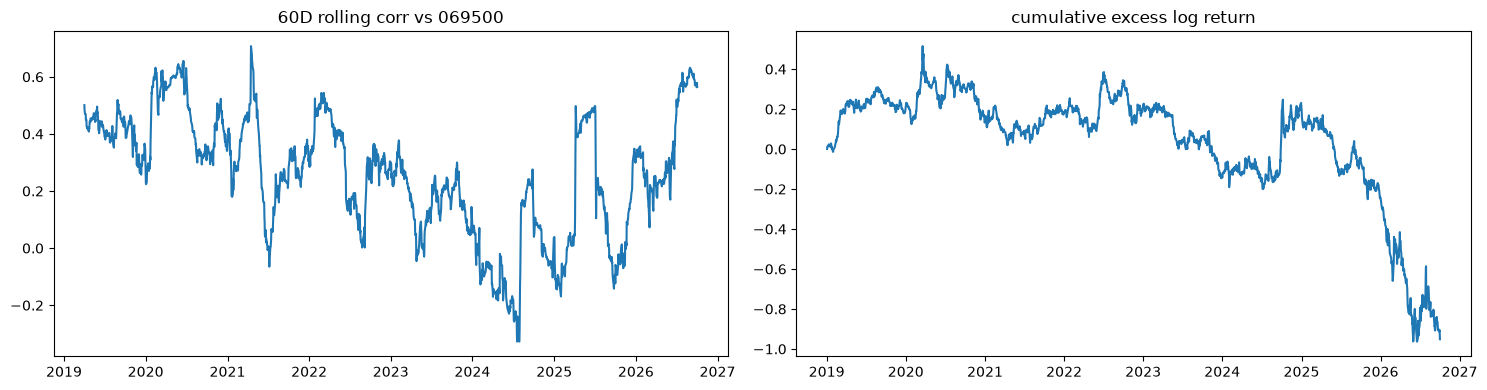

peer 없음 (peer_group= CN_equity )


In [20]:
BETA = CORR = None; BST = {}
bm = row.get("benchmark_proxy_ticker", "")
print("benchmark (index name):", row.get("benchmark", ""), "| proxy ticker:", bm or "(none)")
if bm and bm != TICKER and eu.raw_path(bm).exists():
    b, _ = eu.load_raw(eu.raw_path(bm)); b, _ = eu.engineer_basic(b)
    m = x[["date", "log_ret"]].merge(b[["date", "log_ret"]], on="date", how="outer", suffixes=("", "_bm"), indicator=True)
    n_unm = int((m["_merge"] != "both").sum()); mm = m[m["_merge"] == "both"].dropna(subset=["log_ret", "log_ret_bm"]).sort_values("date")
    BETA = float(np.cov(mm["log_ret"], mm["log_ret_bm"])[0, 1] / mm["log_ret_bm"].var()); CORR = float(mm["log_ret"].corr(mm["log_ret_bm"]))
    rc = mm["log_ret"].rolling(60).corr(mm["log_ret_bm"])
    fig, ax = plt.subplots(1, 2, figsize=(15, 4))
    ax[0].plot(mm["date"], rc); ax[0].set_title(f"60D rolling corr vs {bm}")
    ax[1].plot(mm["date"], (mm["log_ret"] - mm["log_ret_bm"]).cumsum()); ax[1].set_title("cumulative excess log return")
    plt.tight_layout(); plt.show()
    BST = {"benchmark": bm, "n_unmatched_dates": n_unm, "n_matched": len(mm), "beta": BETA, "corr": CORR, "rolling_corr60_min": rc.min()}
else:
    reason = "benchmark_proxy_ticker 미지정" if not bm else ("self" if bm == TICKER else "benchmark raw 없음")
    print("SKIP benchmark:", reason); BST = {"benchmark_skip": reason}
    if bm and bm != TICKER: LIMITATIONS.append("benchmark_missing")  # proxy 미지정(기준 자체·비주식)은 설계상 정상
pg = row.get("peer_group", "")
peers = [t for t in U.loc[(U["peer_group"] == pg) & (U["ticker"] != TICKER), "ticker"] if pg and eu.raw_path(t).exists()]
if peers:
    rets = {TICKER: x.set_index("date")["log_ret"]}
    for t in peers:
        d, _ = eu.load_raw(eu.raw_path(t)); d, _ = eu.engineer_basic(d); rets[t] = d.set_index("date")["log_ret"]
    PC = pd.DataFrame(rets).corr(); display(PC); BST["n_peers"] = len(peers); BST["peer_corr_mean"] = PC[TICKER].drop(TICKER).mean()
else:
    print("peer 없음 (peer_group=", pg, ")")

In [21]:
cap("08", BST)

#### 08 · WHAT WE SEE (raw values)
- `benchmark` = 069500
- `n_unmatched_dates` = 0
- `n_matched` = 1902
- `beta` = 0.1976
- `corr` = 0.2771
- `rolling_corr60_min` = -0.3274

#### General note · WHY IT MATTERS
벤치마크·peer 와의 동조성은 개별 ETF 신호와 시장 공통 신호를 분리(초과수익 정규화)해야 하는지에 대한 근거가 된다.

#### General note · WHAT WE DO NOT KNOW
- benchmark 는 universe 내 대리 ticker 이며 공식 추종지수 자체가 아닐 수 있다.

#### General note · NEXT QUESTION
- 극단 후보를 원수익률이 아니라 benchmark 초과수익으로 정의해야 하는가?

> ETF 고유 해석은 바로 아래 'ETF-specific reading (A card)' 블록 참조


### 08 · WHAT WE SEE — 이 ETF (universe 20종 비교, B 계산)
- **benchmark proxy 와 상관 0.277** — 17종 중 14위(높은 순), 백분위 20%, 069500 의 0.28배 (universe 중앙값 0.655).
- **benchmark proxy 대비 beta 0.20** — 17종 중 15위(높은 순), 백분위 15%, 069500 의 0.20배 (universe 중앙값 0.74).

### ETF-specific reading (A card @69b99d3)
**peer 와 다른 점**

- [OBS] 상위 spearman: 133690 0.291, 091230 0.272, 069500 0.269 / 하위: 114800 −0.267, 148070 −0.105, 261240 −0.050.

## 09 Multivariate Structure (diagnostic)

,pc,explained_ratio
0,PC1,0.7379
1,PC2,0.1170
2,PC3,0.0562
3,PC4,0.0493


pc,PC1,PC2,PC3,PC4
log_ret,0.0260,-0.0486,0.9689,-0.1944
abs_ret,0.0660,0.5698,0.0339,-0.3677
roll_vol_20,0.0002,0.3754,0.2084,0.8899
drawdown,-0.0115,0.0311,0.1018,0.0234
range_pct,0.0684,0.7236,-0.0767,-0.1812
volume_robust_z_20,0.9951,-0.0860,-0.0212,0.0420


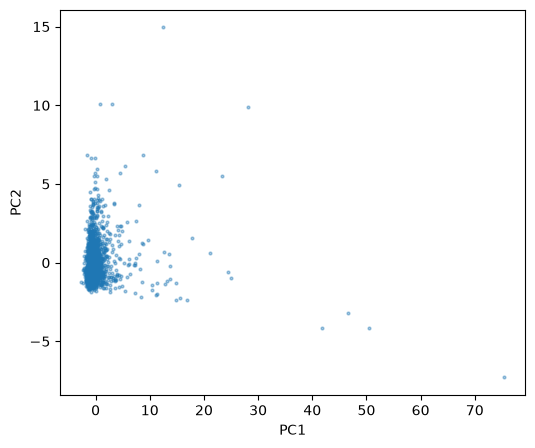

In [22]:
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
feats = ["log_ret", "abs_ret", "roll_vol_20", "drawdown"] + (["range_pct"] if "range_pct" in x else []) + (["volume_robust_z_20"] if HAS_VOL else [])
F = x[feats].replace([np.inf, -np.inf], np.nan).dropna()
Z = RobustScaler().fit_transform(F); pca = PCA(n_components=min(len(feats), 4), random_state=0).fit(Z)
EVR = pd.DataFrame({"pc": [f"PC{i+1}" for i in range(pca.n_components_)], "explained_ratio": pca.explained_variance_ratio_}); display(EVR)
LOAD = pd.DataFrame(pca.components_.T, index=feats, columns=EVR["pc"]); display(LOAD)
S = pca.transform(Z); plt.figure(figsize=(6, 5)); plt.scatter(S[:, 0], S[:, 1], s=4, alpha=.4); plt.xlabel("PC1"); plt.ylabel("PC2"); plt.show()
PC1 = float(pca.explained_variance_ratio_[0])

In [23]:
cap("09", {"n_rows_used": len(F), "features": ", ".join(feats), "pc1_ratio": PC1, "pc2_ratio": float(pca.explained_variance_ratio_[1]),
           "pc1_top_loading": LOAD["PC1"].abs().idxmax()})

#### 09 · WHAT WE SEE (raw values)
- `n_rows_used` = 1882
- `features` = log_ret, abs_ret, roll_vol_20, drawdown, range_pct, volume_robust_z_20
- `pc1_ratio` = 0.7379
- `pc2_ratio` = 0.117
- `pc1_top_loading` = volume_robust_z_20

#### General note · WHY IT MATTERS
여러 feature 가 소수의 축으로 요약되는지는 다변량 정규화·차원 축소가 필요한지에 대한 진단이다.

#### General note · WHAT WE DO NOT KNOW
- PCA 는 선형·전체표본 진단이며, 축의 의미를 확정하지 않는다.

#### General note · NEXT QUESTION
- PC1 이 주로 변동성 축인가, 방향 축인가 — 이것이 ETF 간에 일관적인가?

> ETF 고유 해석은 바로 아래 'ETF-specific reading (A card)' 블록 참조


### 09 · WHAT WE SEE — 이 ETF (universe 20종 비교, B 계산)
- **PCA PC1 설명비율 73.8%** — 20종 중 3위(높은 순), 백분위 90%, 069500 의 1.36배 (universe 중앙값 50.2%).

## 10 Questions Discovered (SEED only — ACCEPTED/REJECTED 금지)

In [24]:
Q = []
def seed(cond, scope, stmt, ev):
    if cond: Q.append({"id": f"{TICKER}-Q{len(Q)+1:02d}", "scope": scope, "statement": stmt, "status": "SEED", "evidence": ev})
seed(K["ex_kurt"] > 5 and K["ex_kurt_trim3"] > 5, "distribution", "꼬리가 두꺼워 정규 가정 z 정규화가 부적합할 수 있다", f"ex_kurt={K['ex_kurt']:.2f}, trim3={K['ex_kurt_trim3']:.2f}")
seed(ZERO_VOL_RATIO > .01, "volume", "거래량 0 일이 많아 거래량 baseline 이 불안정할 수 있다", f"zero_vol_ratio={ZERO_VOL_RATIO:.3f}")
seed(MAX_DD < -.30, "drawdown", "깊은 낙폭 구간이 정규화 창을 지배할 수 있다", f"max_dd={MAX_DD:.3f}")
seed(abs(ACF_ABS[0]) > .2, "volatility", "변동성 군집이 강해 시간가변 baseline 이 필요할 수 있다", f"acf_absret_lag1={ACF_ABS[0]:.3f}")
seed(not HAS_VOL, "volume", "거래량 부재 — 거래량 기반 후보 정의 불가", "has_volume=False")
seed(CORR is not None and CORR > .9, "benchmark", "benchmark 와 거의 동조 — 초과수익 기준 후보 정의 검토", f"corr={CORR}")
QT = pd.DataFrame(Q, columns=["id", "scope", "statement", "status", "evidence"]); display(QT)

,id,scope,statement,status,evidence
0,192090-Q01,drawdown,깊은 낙폭 구간이 정규화 창을 지배할 수 있다,SEED,max_dd=-0.414


## 11 Observation → Implication → Next Question

In [25]:
SUM = pd.DataFrame([
  ("03", "ann_vol / ex_kurt / ex_kurt_trim3", f"{K['ann_vol']:.3f} / {K['ex_kurt']:.2f} / {K['ex_kurt_trim3']:.2f}", eu.NEXT_Q["03"]),
  ("04", "acf_absret_lag1", f"{ACF_ABS[0]:.3f}", eu.NEXT_Q["04"]),
  ("06", "max_dd (date)", f"{MAX_DD:.3f} ({MAX_DD_DATE})", eu.NEXT_Q["06"]),
  ("07", "n_abs_z3 / n_abs_q95", f"{N_ABS3} / {int(x['abs_q95'].sum())}", eu.NEXT_Q["07"]),
  ("08", "corr / beta vs benchmark", f"{CORR} / {BETA}", eu.NEXT_Q["08"]),
  ("09", "pc1_ratio", f"{PC1:.3f}", eu.NEXT_Q["09"]),
], columns=["section", "observation", "number", "next_question"]); display(SUM)
display(Markdown(eu.PLACEHOLDER))

,section,observation,number,next_question
0,03,ann_vol / ex_kurt / ex_kurt_trim3,0.203 / 6.11 / 3.14,꼬리 두께를 감안할 때 z-score 대신 robust/분위수 기반 정규화가 필요한가?
1,04,acf_absret_lag1,0.196,baseline 창 길이(20 vs 60)를 무엇으로 고를 것인가?
2,06,max_dd (date),-0.414 (2024-02-02),극단일 이후 며칠까지를 이벤트 창으로 볼 것인가?
3,07,n_abs_z3 / n_abs_q95,33 / 96,후보 정의 간 불일치가 큰 날들은 어떤 공통 특성을 갖는가?
4,08,corr / beta vs benchmark,0.2770526117984563 / 0.1976009713582236,극단 후보를 원수익률이 아니라 benchmark 초과수익으로 정의해야 하는가?
5,09,pc1_ratio,0.738,"PC1 이 주로 변동성 축인가, 방향 축인가 — 이것이 ETF 간에 일관적인가?"


> ETF 고유 해석은 바로 아래 'ETF-specific reading (A card)' 블록 참조

### ETF-specific reading (A card @69b99d3)
**WHAT WE SEE / WHY IT MATTERS / WHAT WE DO NOT KNOW / NEXT QUESTION**

- WHAT WE SEE [OBS]: 한국 시장과 거의 따로 움직이고(상관 0.27), 가장 큰 사건(2024-10 +10.3%)도 한국 시장은 조용했던 날이다.
- WHY IT MATTERS [ANA]: 포트폴리오 분산 관점에선 매력적이지만, 중국 휴장일에 KRX 가격만 움직이면 'NAV 와 다른 가격'에 사고팔 위험이 있다.
- WHAT WE DO NOT KNOW [ANA]: 그날의 NAV·괴리율 데이터가 없어 premium 크기를 직접 확인할 수 없다. 52일의 0 수익률이 휴장과 겹치는지도 아직 미확인.
- NEXT QUESTION [PROJ]: 중국 휴장일(KRX 개장) 수익률의 분산과 다음 중국 개장일 수익률은 음(−)의 관계인가?

**Hypothesis candidates**

- HC-192090-1 | TESTABLE | 중국 휴장 중 KRX 거래일의 수익률은 중국 재개 첫날 일부 되돌려진다 | 2024-10-02 +10.3% → 10-08 −7.0%, vr 15~18배
  - RQ: 중국 휴장 구간 누적 r 와 재개일 r 의 상관이 음인가? / H0: 상관 = 0 / H1: 상관 < 0
- HC-192090-2 | OBSERVED | 우주 내 가장 독립적인 주식 ETF(시장 공통 충격 참여 최소) | spearman 069500 0.269, common shock 12/55
- HC-192090-3 | SEED | 변동성 군집이 약해 과거 변동성으로 미래 변동성 예측력이 낮다 | acf_abs20 0.010, p90/p10 2.40

## 12 Profile Export

In [26]:
PROFILE = {"slot": SLOT, "ticker": TICKER, "name": row.get("name"), "asset_scope": row.get("asset_scope"), "category": row.get("category"),
  "peer_group": row.get("peer_group"), "leverage_inverse": row.get("leverage_inverse"), "start": START, "end": END, "n_obs": N,
  "ann_vol": K["ann_vol"], "mean_ret": K["mean"], "skew": K["skew"], "ex_kurt": K["ex_kurt"], "ex_kurt_trim3": K["ex_kurt_trim3"], "p01": K["p01"], "p99": K["p99"],
  "max_dd": MAX_DD, "max_dd_date": MAX_DD_DATE, "recovery_days": RECOVERY_DAYS, "zero_vol_ratio": ZERO_VOL_RATIO, "vol_of_vol": VOL_OF_VOL,
  "acf_absret_lag1": ACF_ABS[0], "acf_sqret_lag1": ACF_SQ[0], "n_pos_z3": N_POS3, "n_neg_z3": N_NEG3, "n_abs_z3": N_ABS3,
  "beta_vs_benchmark": BETA, "corr_vs_benchmark": CORR, "pca_pc1_ratio": PC1, "price_policy": PROV["price_policy"],
  "has_volume": HAS_VOL, "rows_raw": PROV["rows_raw"], "n_duplicate_dates": PROV["n_duplicate_dates"],
  "run_limitations": sorted(set(LIMITATIONS))}
out = eu.save_profile(PROFILE, ROOT / "data" / "interim" / "profiles" / f"{TICKER}.json")
print("saved", out); PROFILE

saved /home/sieg/projects-wsl/hongik_univ_26_2/SA/.worktrees/SA_ETF/b/data/interim/profiles/192090.json


{'slot': 15,
 'ticker': '192090',
 'name': 'TIGER 차이나CSI300',
 'asset_scope': 'foreign_equity',
 'category': 'broad_market',
 'peer_group': 'CN_equity',
 'leverage_inverse': 'none',
 'start': Timestamp('2019-01-02 00:00:00'),
 'end': Timestamp('2026-10-02 00:00:00'),
 'n_obs': 1903,
 'ann_vol': np.float64(0.2029945816355147),
 'mean_ret': np.float64(0.0003456393398098552),
 'skew': np.float64(0.04355230025986782),
 'ex_kurt': np.float64(6.106996664240727),
 'ex_kurt_trim3': 3.143141187595872,
 'p01': np.float64(-0.03372085766133795),
 'p99': np.float64(0.03425642948859865),
 'max_dd': -0.4143004851666269,
 'max_dd_date': datetime.date(2024, 2, 2),
 'recovery_days': 650,
 'zero_vol_ratio': 0.0,
 'vol_of_vol': 0.41111812864512937,
 'acf_absret_lag1': 0.19571116360712887,
 'acf_sqret_lag1': 0.2553589837657636,
 'n_pos_z3': 18,
 'n_neg_z3': 15,
 'n_abs_z3': 33,
 'beta_vs_benchmark': 0.1976009713582236,
 'corr_vs_benchmark': 0.2770526117984563,
 'pca_pc1_ratio': 0.7379289420254753,
 'price_